# 04 · Question generation

**Goal:** turn each detected amenity into questions a traveller would actually ask before booking. The questions should be about function, size, quality or special features, not a description of what is already visible.

## How I got to Gemini
I tried three families of models, and each step showed what the task really needed.

| Stage | Models | Input | What happened |
|---|---|---|---|
| 1 · Text only | Flan-T5 Base, Flan-T5 Large | detection summary (label, confidence, prompt type) | Grammatical, but generic and repetitive. The label alone does not carry enough to reason about. |
| 2 · Captioning | BLIP-2 | cropped image | Grounded in the image, but it mostly listed what was visible. Built for captions, not for reasoning about what matters to a guest. |
| 3 · Instruction-tuned multimodal | Gemini 2.5 Flash, 2.5 Pro, 3.0 Pro | cropped image + task prompt | Follows instructions and reasons about the traveller's intent. |

I also tried Llama 3 (8B and 70B via Groq) early on as a quick, low-cost way to prototype the workflow before moving to production-grade models.

Same bathtub photo, one question from each stage (from the saved outputs):

In [1]:
import sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "src"))

from amenity_qgen import config, plotting
from amenity_qgen.plotting import SERIES, MUTED, TEXT, TEXT_2

plotting.use_style()
pd.set_option("display.max_colwidth", 120)
FIG = ROOT / "results" / "figures"
AMENITIES = ["bathtub", "kettle", "hairdryer", "mirror", "tv"]
NAMES = {"bathtub": "Bathtub", "kettle": "Kettle", "hairdryer": "Hairdryer", "mirror": "Mirror", "tv": "TV"}

In [2]:
pd.read_csv(ROOT / "results" / "generation" / "exploration_examples.csv")[["stage", "model", "input", "question"]]

,stage,model,input,question
0,1 · text only,Flan-T5 Base,"detection summary (label, confidence, prompt type)",What type of amenity does a bathtub have?
1,1 · text only,Flan-T5 Large,"detection summary (label, confidence, prompt type)",What is the name of the hotel's bathtub?
2,2 · captioning,BLIP-2,cropped image,Is the bathtub with a toilet in a small bathroom?
3,2 · captioning,BLIP-2,cropped image,Does the bathtub have a shower and toilet?
4,3 · instruction-tuned,Gemini 3.0 Pro,cropped image + task prompt,Does the bathroom layout include both a bathtub and a separate walk-in shower?
5,3 · instruction-tuned,Gemini 3.0 Pro,cropped image + task prompt,Does the bathtub appear deep enough for a comfortable full-body soak?


## Prompt
The prompt sets the role (helping a traveller decide on trivago), names the amenity, gives the rules (functionality, size, quality, luxury features, one aspect per question), and shows good and bad examples for that amenity. The bad examples do a lot of work: they steer the model away from questions the photo already answers.

In [3]:
from amenity_qgen.prompts import build_general_prompt
print(build_general_prompt("kettle"))

You are an AI assistant helping travelers make hotel booking decisions on Trivago.

A guest is viewing this kettle image to evaluate if this hotel accommodation meets their needs.

**Your Task**: Generate 5 practical, decision-relevant questions a traveler would ask about this kettle.

**Requirements**:
1. Focus on FUNCTIONALITY, SIZE, QUALITY, or LUXURY FEATURES
2. Questions should help the guest DECIDE whether to book
3. Use natural language (how people actually talk)
4. Be specific to what's visible in the image
5. Each question should address a different aspect

**Good Examples**:
- "Is this an electric kettle or a stovetop model?"
- "What is the capacity of the kettle - can it boil enough for two cups?"
- "Does the kettle have temperature control settings or just on/off?"
- "Is this a rapid-boil kettle or a standard model?"
- "Are complimentary tea, coffee, or other beverages provided with the kettle?"

**Bad Examples** (avoid these):
- "Does the kettle boil water? (that's its onl

In [4]:
pd.Series(config.GENERATION_CONFIG, name="value").to_frame()

,value
temperature,0.70
top_p,0.95
max_output_tokens,2048.00


- **Temperature 0.7:** enough variety to adapt to each photo, without the unstable phrasing seen at higher values.
- **Top-p 0.95:** cuts off unlikely tokens while keeping natural wording.
- **2,048 max tokens:** a safety margin. Real responses used 300 to 350 tokens.

The same settings were used for all three Gemini models, so the differences come from the models themselves.

## Running generation
Generation ran on Vertex AI inside trivago's cloud project. The code is here for reference; `RUN_GENERATION` is off, and the notebook uses the saved outputs in `results/generation`.

In [5]:
RUN_GENERATION = False

if RUN_GENERATION:
    from amenity_qgen.generation import get_client, generate_questions
    client = get_client()          # needs GOOGLE_CLOUD_PROJECT or GEMINI_API_KEY
    for model_name in config.GEMINI_MODELS:
        for _, det in detections.iterrows():
            questions = generate_questions(client, model_name, image_path(det), [det.x1, det.y1, det.x2, det.y2], det.label)

In [6]:
gen = {am: pd.read_csv(ROOT / "results" / "generation" / f"questions_{am}_all_models.csv") for am in AMENITIES}
MODELS = {"2_5_flash": "Gemini 2.5 Flash", "2_5_pro": "Gemini 2.5 Pro", "3_pro_preview": "Gemini 3.0 Pro Preview"}
pd.DataFrame({"detections": {NAMES[a]: len(d) for a, d in gen.items()}, "questions per model": {NAMES[a]: 5 * len(d) for a, d in gen.items()}})

,detections,questions per model
Bathtub,276,1380
Kettle,183,915
Hairdryer,201,1005
Mirror,627,3135
TV,267,1335


## Comparing the three Gemini models
**Semantic similarity to real traveller questions.** I wrote 25 reference questions (5 per amenity) from hotel reviews, informal interviews and common traveller concerns, phrased the way people actually talk. For each model and amenity, 25 generated questions (fallbacks removed) were scored with BERTScore against the closest reference.

In [7]:
refs = json.load(open(ROOT / "results" / "generation" / "reference_questions.json"))
pd.DataFrame(refs).rename(columns=NAMES)

,Bathtub,TV,Kettle,Hairdryer,Mirror
0,Is there a bathtub or just a shower?,Can I watch Netflix or stream stuff on the TV?,Is there a kettle in the room to make tea or coffee?,Do they give you a hairdryer in the room?,Is there a full-length mirror in the room?
1,Can you actually stretch out and relax in the tub?,Is the TV big enough to see from the bed?,Can it make more than one cup at a time?,Is it strong enough or just one of those weak ones?,Is the bathroom mirror good for doing makeup or shaving?
2,Does the tub have jets or anything fancy?,Is it on the wall or sitting on a table?,Does the kettle have any settings or is it just on/off?,Does it have heat settings or just one speed?,Do they have a small magnifying mirror?
3,Is the bathtub clean and modern looking?,Can I plug in my laptop or device easily?,Do they give you tea bags or coffee with it?,Can you use it easily near a mirror?,Is there enough light near the mirror?
4,Is there space near the tub to keep your stuff like soap or shampoo?,Is it a good quality TV or kind of old?,Is it a decent kettle or just something basic?,Does it come with any attachments like a diffuser?,Does the mirror fog up after a shower?


In [8]:
RUN_BERTSCORE = False   # needs the bert-score package and a model download
if RUN_BERTSCORE:
    from amenity_qgen.quality import bertscore_vs_references

bert = pd.read_csv(ROOT / "results" / "generation" / "bertscore_by_model.csv")
table = bert.pivot(index="model", columns="amenity", values="bertscore")[AMENITIES].rename(columns=NAMES)
table["overall"] = table.mean(axis=1)
table.round(3)

amenity,Bathtub,Kettle,Hairdryer,Mirror,TV,overall
model,,,,,,
Gemini 2.5 Flash,0.705,0.686,0.717,0.704,0.686,0.700
Gemini 2.5 Pro,0.708,0.696,0.684,0.707,0.678,0.695
Gemini 3.0 Pro Preview,0.719,0.698,0.694,0.728,0.697,0.707


**Reliability.** Every generated question goes through a rule-based quality gate. A question is flagged as a *fallback* if it is shorter than 10 characters, matches a generic pattern ("what is the overall quality…", "would this … meet…"), or asks something the photo already answers ("is there a bathtub?"). Flagged questions are replaced by amenity-specific templates, so every detection always ends up with a full, well-formed set. The fallback rate is the share of questions that needed replacing.

In [9]:
from amenity_qgen.quality import fallback_rate

rows = []
for suffix, model in MODELS.items():
    for am in AMENITIES:
        qs = [q for i in range(1, 6) for q in gen[am][f"{suffix}_question_{i}"]]
        f, n, r = fallback_rate(qs, am)
        rows.append(dict(model=model, amenity=am, questions=n, fallbacks=f, rate=r))
fb = pd.DataFrame(rows)
fb.to_csv(ROOT / "results" / "generation" / "fallback_rates.csv", index=False)
by_model = fb.groupby("model")[["questions", "fallbacks"]].sum().assign(rate=lambda d: 100 * d.fallbacks / d.questions)
by_model.round(2)

,questions,fallbacks,rate
model,,,
Gemini 2.5 Flash,7770,733,9.43
Gemini 2.5 Pro,7770,780,10.04
Gemini 3.0 Pro Preview,7770,610,7.85


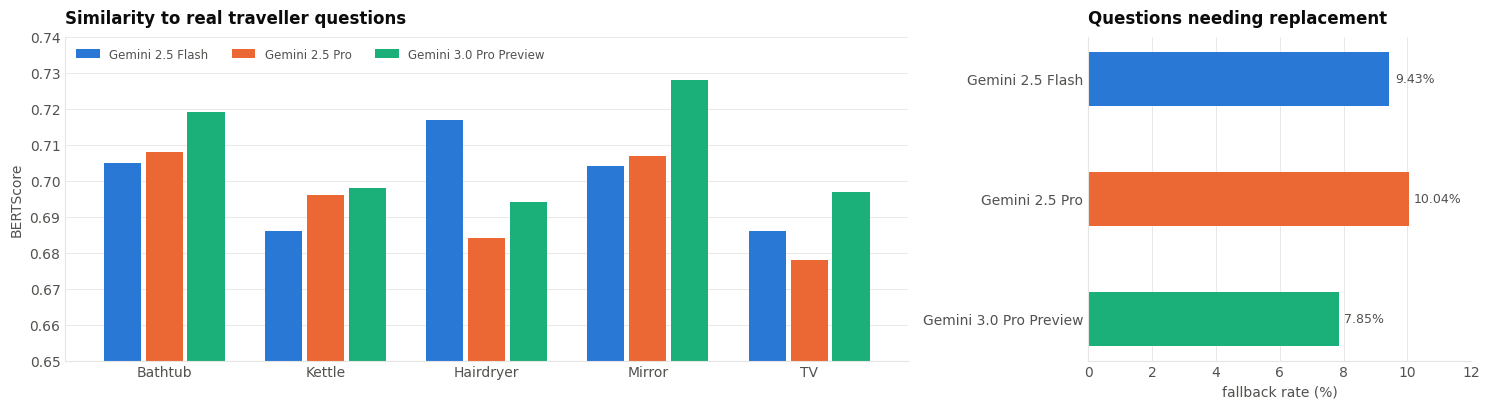

In [10]:
order = list(MODELS.values())
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 4.2), gridspec_kw={"width_ratios": [2.2, 1]})
x = np.arange(len(AMENITIES)); w = 0.26
for k, m in enumerate(order):
    v = bert[bert.model == m].set_index("amenity").loc[AMENITIES, "bertscore"]
    a1.bar(x + (k - 1) * w, v, w - 0.03, color=SERIES[k], label=m)
a1.set_xticks(x); a1.set_xticklabels([NAMES[a] for a in AMENITIES]); a1.set_ylim(0.65, 0.74); a1.grid(axis="x", visible=False)
a1.set_ylabel("BERTScore"); a1.set_title("Similarity to real traveller questions"); a1.legend(ncol=3, fontsize=8.5, loc="upper left")
bars = a2.barh(order[::-1], by_model.loc[order[::-1], "rate"], color=[SERIES[2], SERIES[1], SERIES[0]], height=0.45)
for b in bars:
    a2.annotate(f"{b.get_width():.2f}%", (b.get_width(), b.get_y() + b.get_height() / 2), xytext=(4, 0), textcoords="offset points", va="center", fontsize=9, color=TEXT_2)
a2.set_xlim(0, 12); a2.set_xlabel("fallback rate (%)"); a2.set_title("Questions needing replacement"); a2.grid(axis="y", visible=False)
plt.tight_layout(); fig.savefig(FIG / "gen_model_comparison.png"); plt.show()

**Why Gemini 3.0 Pro.** It has the highest overall BERTScore (0.707) and the lowest fallback rate (7.85% of 7,770 questions). The BERTScore gap is under 2%, so the score alone was not the reason. The deciding factor was behaviour under harder prompts. When I added traveller-profile conditioning (notebook 05), 2.5 Flash drifted into surface-level rewording and 2.5 Pro sometimes blurred the profiles together. 3.0 Pro kept the questions distinct and on-topic. Cost and latency were secondary, since this was an exploratory study rather than a production optimisation.

## Reliability by amenity (Gemini 3.0 Pro)

,questions,fallbacks,rate
amenity,,,
Bathtub,1380,156,11.30
Kettle,915,78,8.52
Hairdryer,1005,26,2.59
Mirror,3135,341,10.88
TV,1335,9,0.67


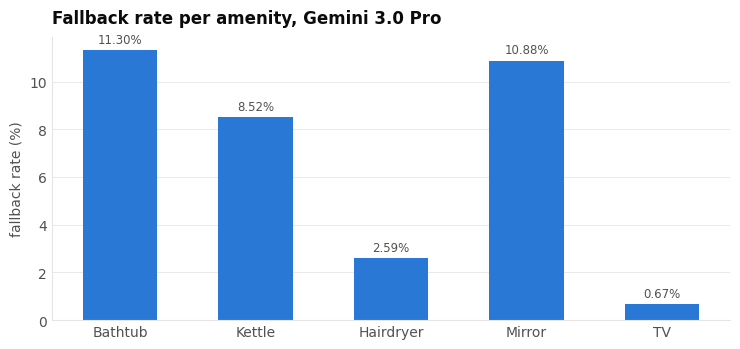

In [11]:
g3 = fb[fb.model == "Gemini 3.0 Pro Preview"].set_index("amenity").loc[AMENITIES]
display(g3[["questions", "fallbacks", "rate"]].rename(index=NAMES).round(2))

fig, ax = plt.subplots(figsize=(7.5, 3.6))
bars = ax.bar([NAMES[a] for a in AMENITIES], g3.rate, color=SERIES[0], width=0.55)
plotting.label_bars(ax, bars, "{:.2f}%")
ax.set_ylabel("fallback rate (%)"); ax.set_title("Fallback rate per amenity, Gemini 3.0 Pro"); ax.grid(axis="x", visible=False)
plt.tight_layout(); fig.savefig(FIG / "gen_fallback_by_amenity.png"); plt.show()

Reliability follows how standardised the object looks. TVs are rectangles with well-known features (0.67%). Bathtubs and mirrors vary a lot in shape, framing and reflections (around 11%). That points to amenity-specific prompt work rather than a global model change.

## One photo, three models

In [12]:
f = "image_205_jpg.rf.6146aa0b31cde49cf0d6d0d9094170ea.jpg"
row = gen["tv"][gen["tv"].image == f].sort_values("score", ascending=False).iloc[0]
pd.DataFrame({m: [row[f"{s}_question_{i}"] for i in range(1, 6)] for s, m in MODELS.items()}, index=[f"Q{i}" for i in range(1, 6)])

,Gemini 2.5 Flash,Gemini 2.5 Pro,Gemini 3.0 Pro Preview
Q1,Is this a smart TV with access to streaming services like Netflix or Hulu?,"Is this a smart TV with built-in apps like Netflix, or can I cast from my phone?",What is the approximate screen size of this flat-screen TV?
Q2,What is the approximate screen size of this wall-mounted TV?,What is the approximate screen size of this TV in inches?,Does the TV have smart capabilities for streaming apps like Netflix or YouTube?
Q3,Does the TV offer high-definition (HD) or 4K resolution for a better viewing experience?,Are there easily accessible HDMI ports to connect my own laptop or gaming console?,Is the wall mount adjustable to tilt or swivel the screen for better viewing angles?
Q4,Are there easily accessible HDMI or USB ports on the TV to connect my own devices?,Is the picture quality in HD or 4K?,Are the HDMI ports easily accessible for connecting personal devices like a laptop?
Q5,Can the TV be angled or swiveled for comfortable viewing from different areas of the room?,Does the channel lineup include premium options like sports or movie channels?,Is the TV positioned at a comfortable height for watching from the bed?


## Takeaways
- The task needs **intent-aware reasoning grounded in the image**. Text-only models lacked the image, and a captioning model lacked the reasoning.
- Prompt design is the main control: rules plus good and bad examples keep questions practical and away from the obvious.
- Model differences were small on similarity and larger on stability. Gemini 3.0 Pro was the most reliable choice for the profile work that followed.